In [1]:
import os
from dotenv import load_dotenv
from google import genai
from google.genai import types
from PIL import Image
from IPython.display import display, Markdown, HTML
import time

# 1. Load API Key from .env
load_dotenv()
api_key = os.getenv("GOOGLE_API_KEY")

# 2. Initialize the Client
client = genai.Client(api_key=api_key)

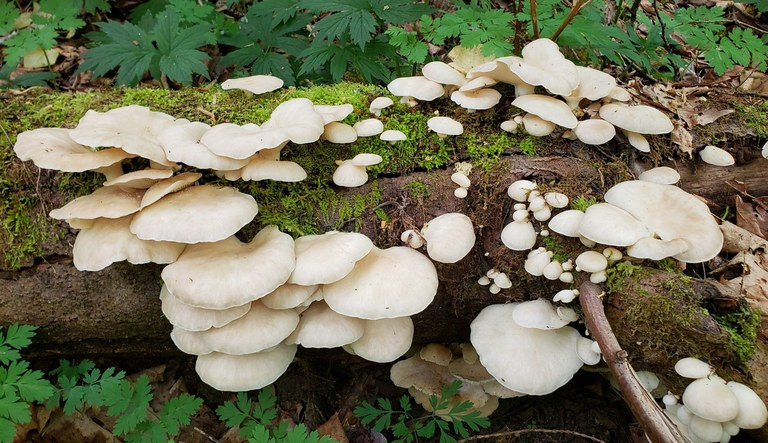

In [2]:
# 3. Load local image
image_path = "../assets/mushroom.jpg" # Change this filename
img = Image.open(image_path)
display(img) # See the image in notebook

In [3]:
def ask_gemini(prompt, model_id="gemini-2.5-flash"):
    """
    Sends a prompt to Gemini and displays the response 
    alongside a styled token usage dashboard.
    """
    try:
        # 1. Call the model
        response = client.models.generate_content(
            model=model_id,
            contents=prompt,
            # We enable a thinking budget to see 'thoughts_token_count'
            config=types.GenerateContentConfig(
                thinking_config=types.ThinkingConfig(include_thoughts=True)
            )
        )

        # 2. Extract Token Metadata
        usage = response.usage_metadata
        prompt_t = usage.prompt_token_count
        cand_t = usage.candidates_token_count
        # thoughts_token_count is specific to reasoning models
        think_t = getattr(usage, 'thoughts_token_count', 0) 
        total_t = usage.total_token_count

        # 3. Create the Beautiful Dashboard
        dashboard_html = f"""
        <div style="font-family: sans-serif; border: 1.5px solid #333; border-radius: 10px; 
                    padding: 15px; background-color: #121212; color: #e0e0e0; 
                    max-width: 450px; margin-top: 20px; box-shadow: 0 4px 8px rgba(0,0,0,0.5);">
            <div style="color: #4ec9b0; font-weight: bold; border-bottom: 1px solid #333; 
                        padding-bottom: 8px; margin-bottom: 12px; display: flex; align-items: center;">
                <span style="margin-right: 8px;">🚀</span> Gemini Engine Stats
            </div>
            <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 8px; font-size: 0.9em;">
                <div style="color: #9cdcfe;">Input Tokens:</div><div style="text-align: right;">{prompt_t}</div>
                <div style="color: #ce9178;">Thinking Tokens:</div><div style="text-align: right;">{think_t}</div>
                <div style="color: #b5cea8;">Output Tokens:</div><div style="text-align: right;">{cand_t}</div>
                <div style="color: #ffffff; font-weight: bold; margin-top: 5px; border-top: 1px solid #333; padding-top: 5px;">Total:</div>
                <div style="text-align: right; font-weight: bold; margin-top: 5px; border-top: 1px solid #333; padding-top: 5px; color: #4ec9b0;">{total_t}</div>
            </div>
        </div>
        """

        # 4. Display Everything
        display(Markdown(response.text))
        display(HTML(dashboard_html))
        
    except Exception as e:
        print(f"Error calling Gemini: {e}")

In [4]:
# --- TEST IT ---
ask_gemini("What is quantum computing? Answer one sentence. Reply in Burmese.")

ကွန်တမ် ကွန်ပျူတင်းသည် ကွန်တမ်စက်ပိုင်းဆိုင်ရာ ဖြစ်စဉ်များဖြစ်သော ထပ်ဆင့်တည်ရှိမှု (superposition) နှင့် ဆက်စပ်မှု (entanglement) တို့ကို အသုံးချ၍ အချက်အလက်များကို တွက်ချက်သည့် နည်းပညာတစ်ရပ် ဖြစ်ပါသည်။

In [ ]:
def ask_gemini_stable(prompt):
    retries = 3
    for i in range(retries):
        try:
            return ask_gemini(prompt) # Call the function we defined earlier
        except Exception as e:
            if "503" in str(e) and i < retries - 1:
                print(f"Server is busy, retrying {i+1} time(s)...")
                time.sleep(2) # 2 seconds rest
                continue
            else:
                raise e

In [6]:
ask_gemini_stable("Write another sentence. Reply in Burmese.")

ဤတွင် နောက်ထပ် ဝါကျတစ်ကြောင်း ရှိပါသည်။